# Lesson 18 — Correlation & regression: inference

*Part 2 · Lesson 18 of 20  ·  data: Ames housing*

**←** [Lesson 17: Chi-square: goodness-of-fit & independence](17-chi-square.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  [Lesson 19: Multiple regression (intro)](19-multiple-regression.ipynb) **→**

**Same idea, another way:**  [Another dataset →](18-regression-inference~another-dataset.ipynb)  ·  [The code behind it →](18-regression-inference~the-code.ipynb)

In the **relationships lesson** we fit a line through the Ames homes and read off a slope: each extra
square foot of living area was worth about **112 more dollars**. But that 112 came from *one sample*
of houses. Draw a different batch of homes and you'd get a slightly different slope. So the honest
question is: **is the slope real, or could the true relationship be flat and we just got lucky?**

This lesson turns the descriptive line into an **inference**. We'll watch the slope wobble from sample
to sample by **resampling** (no formula required), read a **confidence interval** and a **p-value** for
the slope straight off statsmodels, and then check the fine print: the **residual diagnostics** that
decide whether those tidy textbook numbers can be trusted. Spoiler — the Ames data has a famous
**funnel**, and it has a real cost.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
sl.use_course_style()

AMES_URL = 'https://www.openintro.org/data/csv/ames.csv'
ames = sl.load_csv('ames.csv', url=AMES_URL)

# Keep only the rows whose two measurements we'll use.
ames = ames.dropna(subset=['area', 'price'])
print(f'{len(ames):,} homes (Ames, Iowa)')
ames[['area', 'price']].head()

2,930 homes (Ames, Iowa)


,area,price
0,1656,215000
1,896,105000
2,1329,172000
3,2110,244000
4,1629,189900


## 1) The slope is an estimate of something we can't see

When we fit $\hat{y} = b_0 + b_1 x$, the slope $b_1$ is computed from the homes **in our data**. But
imagine the much larger world of all comparable homes that *could* have been sold. There is some
**true** underlying relationship in that world,

$$y = \beta_0 + \beta_1 x + \varepsilon,$$

where $\beta_1$ (Greek "beta-one") is the **population slope** — the real dollars-per-square-foot that
we will never get to observe directly — and $\varepsilon$ is the random scatter of each home around the
line. Our sample slope $b_1$ is an **estimate** of $\beta_1$, in exactly the way a sample mean
$\bar{x}$ estimates a population mean $\mu$ (see the **estimation** lesson). Different samples give
different $b_1$'s, so $b_1$ has its own **sampling distribution** and its own **standard error** — the
typical distance between our estimate and the truth.

Let's start with the single line, just to have our numbers in front of us.

sample slope     b1 = 111.69 dollars per sq ft
sample intercept b0 = 13,290 dollars
correlation       r = 0.707    (R^2 = 0.500)


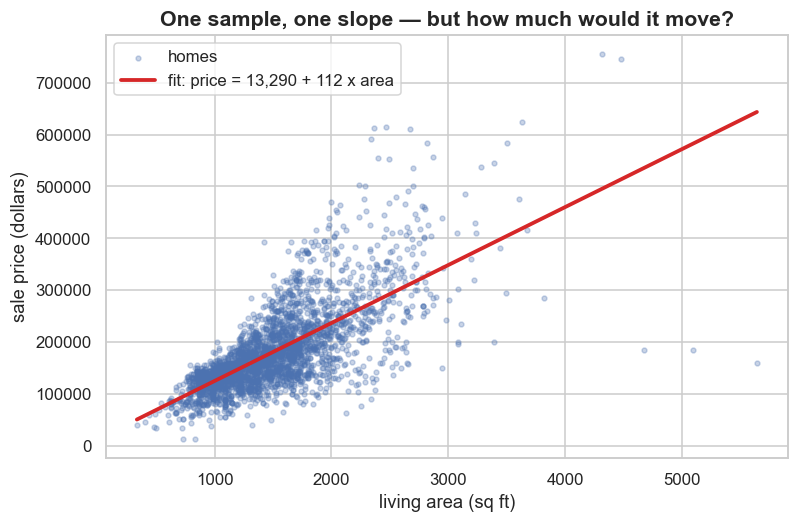

In [2]:
x = ames['area'].to_numpy()
y = ames['price'].to_numpy()

b1, b0 = np.polyfit(x, y, 1)            # numpy returns [slope, intercept]
r = np.corrcoef(x, y)[0, 1]
print(f'sample slope     b1 = {b1:.2f} dollars per sq ft')
print(f'sample intercept b0 = {b0:,.0f} dollars')
print(f'correlation       r = {r:.3f}    (R^2 = {r**2:.3f})')

line_x = np.array([x.min(), x.max()])
fig, ax = plt.subplots()
ax.scatter(x, y, s=10, alpha=0.30, color='#4c72b0', label='homes')
ax.plot(line_x, b0 + b1 * line_x, color='#d62728', lw=2.5,
        label=f'fit: price = {b0:,.0f} + {b1:.0f} x area')
ax.set_xlabel('living area (sq ft)'); ax.set_ylabel('sale price (dollars)')
ax.set_title('One sample, one slope — but how much would it move?')
ax.legend(); plt.show()

## 2) Watch the slope wobble — the sampling distribution, by simulation

Here is the simulation-first heart of the lesson. We don't have other samples lying around, so we
**manufacture** them by **bootstrapping**: draw a new dataset of the same size by sampling rows **with
replacement** from the homes we have, re-fit the line, and record the slope. Repeat thousands of times.
The spread of those slopes *is* the sampling distribution of $b_1$, and its standard deviation *is* the
standard error of the slope — no formula needed.

(Why with replacement? It treats our sample as a stand-in for the population and re-draws from it,
mimicking the act of collecting a fresh dataset. The **bootstrap & permutation** lesson is devoted to
this trick; here we just use it.)

In [3]:
rng = np.random.default_rng(20)        # change this seed to get a different batch of bootstraps
n_boot = 4000
n = len(ames)
idx = np.arange(n)

boot_slopes = np.empty(n_boot)
for i in range(n_boot):
    take = rng.choice(idx, size=n, replace=True)     # a resampled dataset of the same size
    s, _ = np.polyfit(x[take], y[take], 1)
    boot_slopes[i] = s

boot_se = boot_slopes.std(ddof=1)
print(f'Across {n_boot:,} resampled datasets:')
print(f'  average slope          = {boot_slopes.mean():.2f} dollars/sq ft   (centered on our b1 = {b1:.2f})')
print(f'  std of the slopes (SE) = {boot_se:.2f} dollars/sq ft   <- the bootstrap standard error')

Across 4,000 resampled datasets:
  average slope          = 111.85 dollars/sq ft   (centered on our b1 = 111.69)
  std of the slopes (SE) = 4.72 dollars/sq ft   <- the bootstrap standard error


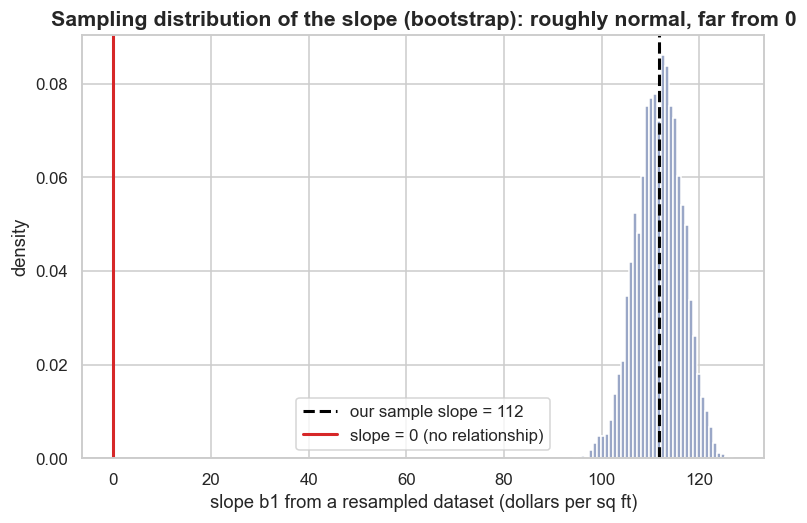

In [4]:
fig, ax = plt.subplots()
ax.hist(boot_slopes, bins=40, color='#9aa7c7', edgecolor='white', density=True)
ax.axvline(b1, color='black', ls='--', lw=2, label=f'our sample slope = {b1:.0f}')
ax.axvline(0, color='#d62728', lw=2, label='slope = 0 (no relationship)')
ax.set_xlabel('slope b1 from a resampled dataset (dollars per sq ft)')
ax.set_ylabel('density')
ax.set_title('Sampling distribution of the slope (bootstrap): roughly normal, far from 0')
ax.legend(); plt.show()

Two things to notice. First, the cloud of slopes is **roughly bell-shaped and centered on our $b_1$** —
the same Central Limit Theorem magic that made sample *means* normal also makes sample *slopes* normal.
Second, the whole hill sits **a long way to the right of zero** (the red line). A slope of 0 would mean
"area tells you nothing about price." That value is nowhere near our pile of plausible slopes — already
a strong hint that the relationship is real, not luck.

### A bootstrap confidence interval for the slope

A 95% confidence interval is just the **middle 95%** of that bootstrap pile — cut off the lowest 2.5%
and the highest 2.5%.

In [5]:
ci_lo, ci_hi = np.percentile(boot_slopes, [2.5, 97.5])
print(f'95% bootstrap CI for the slope: ({ci_lo:.1f}, {ci_hi:.1f}) dollars per sq ft')
print(f'Does this interval contain 0 (no relationship)?  {"yes" if ci_lo <= 0 <= ci_hi else "NO"}')
print('\nPlain English: across plausible datasets, an extra square foot is worth somewhere')
print(f'between about {ci_lo:.0f} and {ci_hi:.0f} dollars. Zero is not in that range.')

95% bootstrap CI for the slope: (102.5, 120.7) dollars per sq ft
Does this interval contain 0 (no relationship)?  NO

Plain English: across plausible datasets, an extra square foot is worth somewhere
between about 102 and 121 dollars. Zero is not in that range.


## 3) The textbook formula — and reading the regression table

Statisticians don't bootstrap every time; there's a classic formula for the standard error of the
slope,

$$\text{SE}(b_1) = \frac{s_e}{\sqrt{\sum (x_i-\bar{x})^2}},$$

where $s_e$ is the spread of the **residuals** (each home's leftover gap — its actual price minus the
price the line predicts). With it you build a **t-statistic** and test the null
hypothesis (see the **hypothesis-testing** lesson):

$$H_0:\ \beta_1 = 0 \quad(\text{area has no linear effect on price}) \qquad
  t = \frac{b_1 - 0}{\text{SE}(b_1)},\quad df = n-2.$$

`statsmodels` does all of this and prints a standard **regression table**. Let's read it line by line.

In [6]:
model = smf.ols('price ~ area', data=ames).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.500
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                     2923.
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        09:54:36   Log-Likelihood:                -36218.
No. Observations:                2930   AIC:                         7.244e+04
Df Residuals:                    2928   BIC:                         7.245e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.329e+04   3269.703      4.064      0.0

The block you care about is the middle table. For the **`area`** row:

- **`coef` = 111.69** — the slope $b_1$: about **112 dollars per extra sq ft** (and `Intercept` = the
  $b_0$ we already saw; recall from the relationships lesson that this "price of a 0-sq-ft house" is not
  meaningful — it only anchors the line's height).
- **`std err` = 2.07** — the textbook $\text{SE}(b_1)$: how much $b_1$ would wobble between samples.
- **`t` = 54.06** — the slope is **54 standard errors away from 0**. Enormous.
- **`P>|t|` = 0.000** — the **p-value**: *if* the true slope were exactly 0, the chance of seeing a
  sample slope this far from 0 is essentially nil. We reject "no relationship."
- **`[0.025  0.975]` = (107.6, 115.7)** — the textbook **95% confidence interval** for $\beta_1$.

And in the header, **`R-squared` = 0.500**: living area alone explains about **half** the variation in
sale price (the other half is location, quality, age, lot size, ...). For a one-predictor regression
$R^2 = r^2$, exactly as in the relationships lesson.

Let's pull those numbers out as values, then rebuild the confidence interval by hand to show the table
is just the formula $b_1 \pm t^{*}\,\text{SE}(b_1)$ in disguise.

In [7]:
b1_hat   = model.params['area']
se_b1    = model.bse['area']
t_stat   = model.tvalues['area']
p_value  = model.pvalues['area']
df       = int(model.df_resid)             # n - 2

print(f'slope b1        = {b1_hat:.2f} dollars/sq ft')
print(f'SE(b1)          = {se_b1:.3f}')
print(f't = b1 / SE(b1) = {t_stat:.2f}   (df = {df})')
print(f'p-value         = {p_value:.2e}')

# Rebuild the 95% CI by hand from the t multiplier:
tstar = stats.t.ppf(0.975, df=df)          # ~1.96 for this many degrees of freedom
lo = b1_hat - tstar * se_b1
hi = b1_hat + tstar * se_b1
print(f'\nt* (95%, df={df}) = {tstar:.3f}')
print(f'hand-built 95% CI = ({lo:.1f}, {hi:.1f})')
print(f'statsmodels   CI = ({model.conf_int().loc["area", 0]:.1f}, {model.conf_int().loc["area", 1]:.1f})   <- identical')

slope b1        = 111.69 dollars/sq ft
SE(b1)          = 2.066
t = b1 / SE(b1) = 54.06   (df = 2928)
p-value         = 0.00e+00

t* (95%, df=2928) = 1.961
hand-built 95% CI = (107.6, 115.7)
statsmodels   CI = (107.6, 115.7)   <- identical


**Interpreting the interval in real words:** we are 95% confident that, across the population these
homes represent, each additional square foot of living area is associated with between about **108 and
116 dollars** of sale price. (As always with confidence intervals — see the **confidence-interval
flagship** — the 95% is a property of the *method's long-run hit rate*, not a probability about this one
interval.) Because the entire interval is **positive and far from 0**, "no relationship" is not a
credible story.

### Do the two methods agree?

We now have two confidence intervals for the same slope: the **bootstrap** one we simulated, and the
**formula** one from statsmodels. Honest methods should roughly agree — let's check.

In [8]:
print('95% CI for the slope, two ways:')
print(f'  bootstrap (simulated)   : ({ci_lo:6.1f}, {ci_hi:6.1f})   width = {ci_hi - ci_lo:5.1f}')
print(f'  statsmodels (formula)   : ({lo:6.1f}, {hi:6.1f})   width = {hi - lo:5.1f}')
print()
print(f'  bootstrap SE = {boot_se:.2f}      formula SE = {se_b1:.2f}')

95% CI for the slope, two ways:
  bootstrap (simulated)   : ( 102.5,  120.7)   width =  18.2
  statsmodels (formula)   : ( 107.6,  115.7)   width =   8.1

  bootstrap SE = 4.72      formula SE = 2.07


Surprise: they **don't** agree as tightly as they should. The bootstrap interval is noticeably
**wider**, and the bootstrap standard error (~4.7) is more than **double** the formula's (~2.07). When
an honest simulation and a textbook formula disagree like this, one of them is leaning on an assumption
that the data is breaking. To find out which, we open up the **residuals**.

## 4) Residual diagnostics — checking the fine print

The slope estimate $b_1$ is trustworthy on its own, but the **standard error, t, p-value, and CI** all
ride on a few assumptions about the residuals $e_i = y_i - \hat{y}_i$. Two pictures check most of them.

### Diagnostic 1 — residuals vs. fitted (the funnel test)

Plot each home's residual against its predicted price. What you **want** is a shapeless, horizontal band
of constant thickness around 0. That would mean the leftover scatter is the same size everywhere — an
assumption with a name: **homoscedasticity** ("equal scatter"). A **curve** signals the straight line is
the wrong shape; a **funnel** that fans open signals **heteroscedasticity** ("unequal scatter"), which
is exactly what breaks the textbook standard errors.

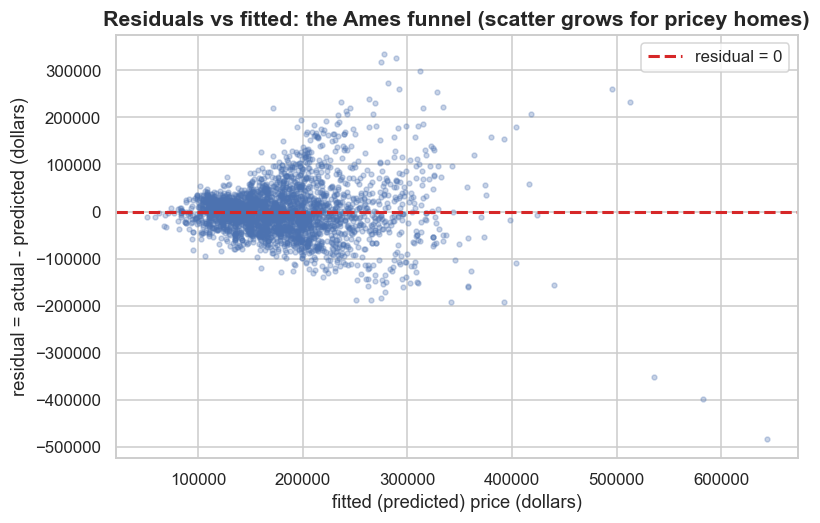

Residuals always average to ~0: mean = -0.00 dollars


In [9]:
fitted = model.fittedvalues
resid = model.resid

fig, ax = plt.subplots()
ax.scatter(fitted, resid, s=10, alpha=0.30, color='#4c72b0')
ax.axhline(0, color='#d62728', lw=2, ls='--', label='residual = 0')
ax.set_xlabel('fitted (predicted) price (dollars)')
ax.set_ylabel('residual = actual - predicted (dollars)')
ax.set_title('Residuals vs fitted: the Ames funnel (scatter grows for pricey homes)')
ax.legend(); plt.show()

print(f'Residuals always average to ~0: mean = {resid.mean():,.2f} dollars')

There it is — the **funnel**. For cheaper homes the residuals huddle close to 0; for expensive homes
they fan out to plus-or-minus a hundred thousand dollars. The scatter is **not** constant, so the data
violates homoscedasticity. That's the assumption the textbook $\text{SE}(b_1)$ formula quietly relies
on, which is **why its standard error was too small** and its CI too narrow. The bootstrap made no such
assumption, so it caught the extra uncertainty.

The fix is to use a standard error that doesn't assume equal scatter — a **robust** (heteroscedasticity-
consistent) standard error. statsmodels gives one with a single argument, and it should land near the
bootstrap.

In [10]:
robust = smf.ols('price ~ area', data=ames).fit(cov_type='HC3')   # robust to unequal scatter
rci = robust.conf_int().loc['area']

print('SE(b1) and 95% CI for the slope, three ways:')
print(f'  classic OLS   : SE = {se_b1:5.2f}   CI = ({lo:6.1f}, {hi:6.1f})')
print(f'  bootstrap     : SE = {boot_se:5.2f}   CI = ({ci_lo:6.1f}, {ci_hi:6.1f})')
print(f'  robust (HC3)  : SE = {robust.bse["area"]:5.2f}   CI = ({rci[0]:6.1f}, {rci[1]:6.1f})')
print('\nThe robust formula and the bootstrap agree -- both honestly admit the slope is')
print('less certain than the classic OLS table claimed. The slope itself is unchanged.')

SE(b1) and 95% CI for the slope, three ways:
  classic OLS   : SE =  2.07   CI = ( 107.6,  115.7)
  bootstrap     : SE =  4.72   CI = ( 102.5,  120.7)
  robust (HC3)  : SE =  4.81   CI = ( 102.3,  121.1)

The robust formula and the bootstrap agree -- both honestly admit the slope is
less certain than the classic OLS table claimed. The slope itself is unchanged.


The robust standard error (~4.8) and the bootstrap (~4.7) match, and both are far above the naive OLS
2.07. The good news: even with the honest, wider interval, the slope is *still* overwhelmingly far from
0 — "area predicts price" survives easily. The funnel didn't change *whether* the relationship is real;
it changed *how precisely* we can pin the number down.

### Diagnostic 2 — the normal Q-Q plot of residuals

The second assumption behind the t-based p-value is that the residuals are roughly **normally
distributed**. A **Q-Q (quantile-quantile) plot** checks this by sorting the residuals and plotting them
against the values a perfect normal would produce. If the residuals are normal, the dots fall on a
straight diagonal; **bent ends** (especially upward at the top right) reveal **heavy tails** — a few
homes that sold for far more than any line would predict.

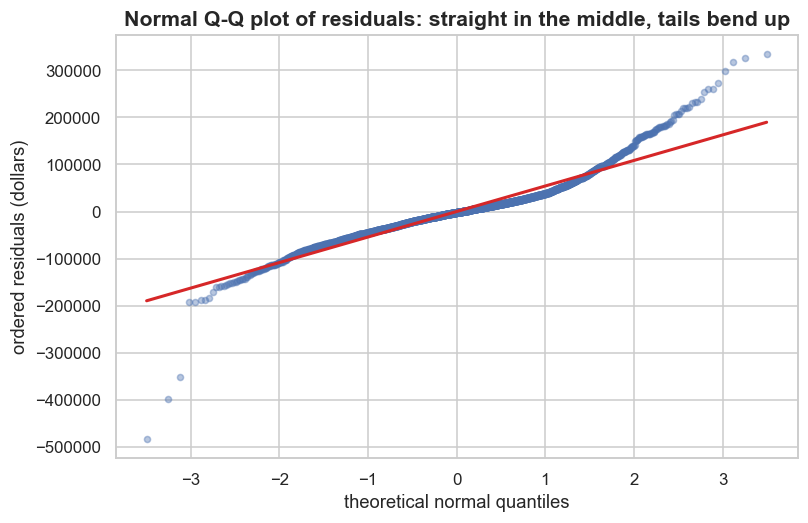

In [11]:
fig, ax = plt.subplots()
stats.probplot(resid, dist='norm', plot=ax)     # builds the Q-Q plot
ax.get_lines()[0].set(marker='o', markersize=4, alpha=0.4, color='#4c72b0')   # the points
ax.get_lines()[1].set(color='#d62728', lw=2)                                  # the ideal line
ax.set_title('Normal Q-Q plot of residuals: straight in the middle, tails bend up')
ax.set_xlabel('theoretical normal quantiles'); ax.set_ylabel('ordered residuals (dollars)')
plt.show()

The middle of the cloud hugs the line nicely, but the **upper tail curls away**: a handful of homes are
much more expensive than a normal model expects (the heavy right tail of house prices). With **2,930**
homes the Central Limit Theorem keeps the test for the *slope* robust to this — large samples forgive
non-normal residuals. Where it bites is **individual prediction intervals** at the high end, which lean
directly on the normal-tail assumption. That's the bridge to our last idea.

## 5) Two very different "intervals" for a prediction

Suppose a 2,000-sq-ft home comes on the market. There are **two** honest questions, and they have very
different answers:

- **Confidence interval for the mean response** — "what is the **average** price of *all* 2,000-sq-ft
  homes?" This is about the height of the regression *line*, so it's fairly tight.
- **Prediction interval for one individual** — "what will **this one** 2,000-sq-ft home sell for?" This
  must also swallow the scatter of individual homes around the line, so it is **much wider**.

The prediction interval is wider because it carries **two** sources of uncertainty (where the line is,
*plus* how far one home strays from it), while the confidence interval carries only the first. Let's get
both from statsmodels.

In [12]:
new = pd.DataFrame({'area': [2000]})
pred = model.get_prediction(new).summary_frame(alpha=0.05)

point   = pred['mean'].iloc[0]
cmean   = (pred['mean_ci_lower'].iloc[0], pred['mean_ci_upper'].iloc[0])   # mean response
indiv   = (pred['obs_ci_lower'].iloc[0],  pred['obs_ci_upper'].iloc[0])    # one new home

print(f'A 2,000 sq ft home -> point prediction: {point:,.0f} dollars\n')
print(f'95% CI for the MEAN price of all 2,000 sq ft homes : ({cmean[0]:,.0f}, {cmean[1]:,.0f})')
print(f'   width = {cmean[1] - cmean[0]:,.0f} dollars  (narrow: just the line height)\n')
print(f'95% PREDICTION interval for ONE 2,000 sq ft home   : ({indiv[0]:,.0f}, {indiv[1]:,.0f})')
print(f'   width = {indiv[1] - indiv[0]:,.0f} dollars  (wide: line + individual scatter)')

A 2,000 sq ft home -> point prediction: 236,678 dollars

95% CI for the MEAN price of all 2,000 sq ft homes : (233,797, 239,559)
   width = 5,762 dollars  (narrow: just the line height)

95% PREDICTION interval for ONE 2,000 sq ft home   : (125,809, 347,546)
   width = 221,737 dollars  (wide: line + individual scatter)


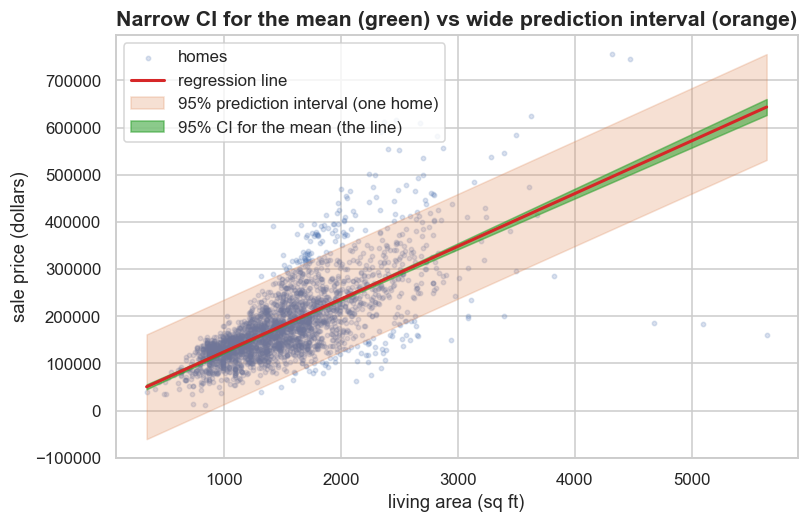

In [13]:
# Both bands across the whole range of areas, drawn over the data.
grid = pd.DataFrame({'area': np.linspace(x.min(), x.max(), 200)})
pf = model.get_prediction(grid).summary_frame(alpha=0.05)

fig, ax = plt.subplots()
ax.scatter(x, y, s=8, alpha=0.20, color='#4c72b0', label='homes')
ax.plot(grid['area'], pf['mean'], color='#d62728', lw=2, label='regression line')
ax.fill_between(grid['area'], pf['obs_ci_lower'], pf['obs_ci_upper'],
                color='#dd8452', alpha=0.25, label='95% prediction interval (one home)')
ax.fill_between(grid['area'], pf['mean_ci_lower'], pf['mean_ci_upper'],
                color='#2ca02c', alpha=0.55, label='95% CI for the mean (the line)')
ax.set_xlabel('living area (sq ft)'); ax.set_ylabel('sale price (dollars)')
ax.set_title('Narrow CI for the mean (green) vs wide prediction interval (orange)')
ax.legend(loc='upper left'); plt.show()

The **green** band (confidence interval for the mean) is a thin ribbon hugging the line — we know its
*height* well. The **orange** band (prediction interval for an individual) is far wider, because any
single home can stray a lot from the line. And here the funnel returns to bite: because the real scatter
**grows** with price while this model assumes it's constant, the straight orange band is roughly the
right size for ordinary homes but **too narrow for the priciest ones**. That is the concrete cost of the
Ames funnel — naive prediction intervals are untrustworthy at the high end, which a residual plot warns
you about *before* you quote a buyer a number.

## Now you try

Predict first, then change a number and re-run:

1. **Re-roll the bootstrap.** Change `np.random.default_rng(20)` to another seed and re-run sections 2-3.
   Does the bootstrap CI for the slope shift much? About how many of your 4,000 resampled slopes ever
   fall below 0?

2. **A different predictor.** Refit with overall quality instead of area:

       q = ames.dropna(subset=['Overall.Qual', 'price'])
       print(smf.ols('price ~ Q("Overall.Qual")', data=q).fit().summary())

   Is its slope's p-value still tiny? Is the $R^2$ bigger or smaller than area's 0.50?

3. **Predict a different home.** In section 5, change `area: [2000]` to `[1200]` and then to `[4000]`.
   Which gets the wider prediction interval, and does the funnel make you trust the 4,000-sq-ft band?

4. **Make the funnel disappear.** Refit on the **log** of price: add a column
   `ames['logprice'] = np.log(ames['price'])`, fit `smf.ols('logprice ~ area', ...)`, and redraw the
   residuals-vs-fitted plot. Is the funnel tamer? (Logging often equalizes scatter on skewed money data.)

## What you learned

- The sample slope $b_1$ is an **estimate** of an unseen **population slope** $\beta_1$; like any
  estimate it has a **sampling distribution** and a **standard error**.
- **Resampling (bootstrap)** builds that sampling distribution directly: re-fit the line on many
  resampled datasets and the spread of slopes *is* the standard error — no formula required.
- The **regression table** (`smf.ols(...).fit().summary()`) hands you the slope (`coef`), its
  `std err`, a `t` and `P>|t|` testing $H_0:\beta_1=0$, and a 95% CI; the CI is just
  $b_1 \pm t^{*}\,\text{SE}(b_1)$, and $R^2$ is the share of $y$'s variation explained.
- **Residuals-vs-fitted** checks for **constant scatter**; the Ames **funnel** (heteroscedasticity)
  makes the classic standard error **too small**, which is why the bootstrap and **robust (HC3)**
  intervals are wider — and more honest.
- A **normal Q-Q plot** checks that residuals are bell-shaped; bent tails (heavy-tailed house prices)
  matter little for the slope test in a big sample but a lot for individual predictions.
- A **confidence interval for the mean response** (where the line sits) is narrow; a **prediction
  interval for one individual** is much wider because it also carries each home's scatter — and the
  funnel makes the high-end prediction interval untrustworthy.

---

**← Previous:** [Lesson 17: Chi-square: goodness-of-fit & independence](17-chi-square.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Next →:** [Lesson 19: Multiple regression (intro)](19-multiple-regression.ipynb)

**Same idea, another way:**  [Another dataset →](18-regression-inference~another-dataset.ipynb)  ·  [The code behind it →](18-regression-inference~the-code.ipynb)